First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

/tmp/ipykernel_9834/144194153.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_9834/144194153.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

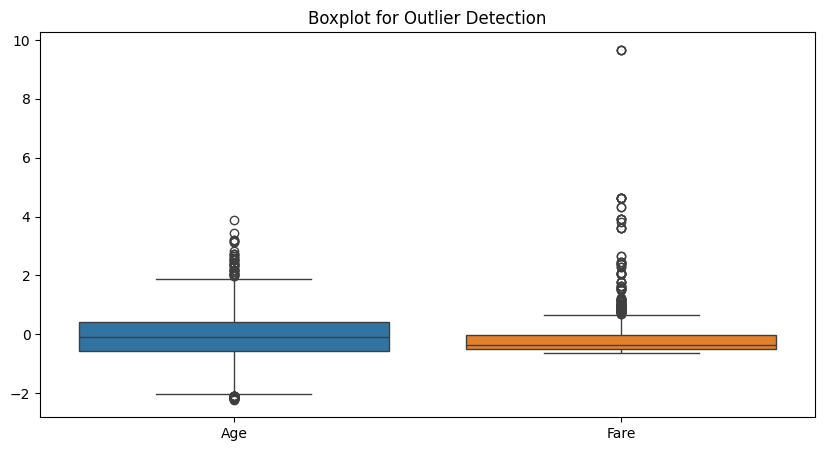


Final Shape After Removing Outliers: (718, 12)

✅ Data preprocessing completed and saved as cleaned_titanic.csv


In [2]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_csv("/content/Titanic-Dataset.csv")  # make sure file is in same folder

# ===============================
# 3. Basic Exploration
# ===============================
print("First 5 rows:\n", df.head())
print("\nInfo:\n")
df.info()

print("\nMissing Values:\n", df.isnull().sum())

# ===============================
# 4. Handle Missing Values
# ===============================

# Fill Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

print("\nAfter Handling Missing Values:\n", df.isnull().sum())

# ===============================
# 5. Encode Categorical Variables
# ===============================

# Convert Sex (Male=1, Female=0)
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# One-hot encoding for Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# ===============================
# 6. Feature Scaling
# ===============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select numerical columns
num_cols = ['Age', 'Fare']

df[num_cols] = scaler.fit_transform(df[num_cols])

# ===============================
# 7. Outlier Detection (Boxplot)
# ===============================
plt.figure(figsize=(10,5))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot for Outlier Detection")
plt.show()

# ===============================
# 8. Remove Outliers (IQR Method)
# ===============================
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df = remove_outliers(df, num_cols)

print("\nFinal Shape After Removing Outliers:", df.shape)

# ===============================
# 9. Save Cleaned Dataset
# ===============================
df.to_csv("cleaned_titanic.csv", index=False)

print("\n✅ Data preprocessing completed and saved as cleaned_titanic.csv")